Found 3 files under test (subXXX only)
After filter: 3 files

== SUBJECT: sub002 ==

[delta_q]
  NOOP:    n=14489 mean=0.2261 std=0.4822
  NonNOOP: n=10593 mean=0.2260 std=0.5262
  Mann-Whitney U p=3.53e-16 (***)

[delta_v]
  NOOP:    n=13650 mean=0.1385 std=0.1538
  NonNOOP: n=9954 mean=0.1735 std=0.1925
  Mann-Whitney U p=8.96e-34 (***)

[H_all]
  NOOP:    n=14489 mean=1.5393 std=0.1869
  NonNOOP: n=10593 mean=1.5903 std=0.1483
  Mann-Whitney U p=2.99e-121 (***)

[p_noop]
  NOOP:    n=14489 mean=0.2566 std=0.1202
  NonNOOP: n=10593 mean=0.1979 std=0.0694
  Mann-Whitney U p=0 (***)

[V_prev(cur_v)]
  NOOP:    n=14489 mean=1.2426 std=0.4749
  NonNOOP: n=10593 mean=1.3780 std=0.4847
  Mann-Whitney U p=1.46e-107 (***)

[vre]
  NOOP:    n=14487 mean=-0.2621 std=0.7287
  NonNOOP: n=10592 mean=-0.3103 std=0.7709
  Mann-Whitney U p=0.000185 (***)

[vre_abs_q]
  NOOP:    n=14487 mean=0.4272 std=0.6459
  NonNOOP: n=10592 mean=0.4564 std=0.6944
  Mann-Whitney U p=0.21 (ns)

[vre_abs_v]
  NOOP: 

/tmp/ipykernel_205723/1676235343.py:329: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["NOOP", "Non-NOOP"], showfliers=False)
/tmp/ipykernel_205723/1676235343.py:329: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["NOOP", "Non-NOOP"], showfliers=False)
/tmp/ipykernel_205723/1676235343.py:329: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["NOOP", "Non-NOOP"], showfliers=False)
/tmp/ipykernel_205723/1676235343.py:329: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; suppor

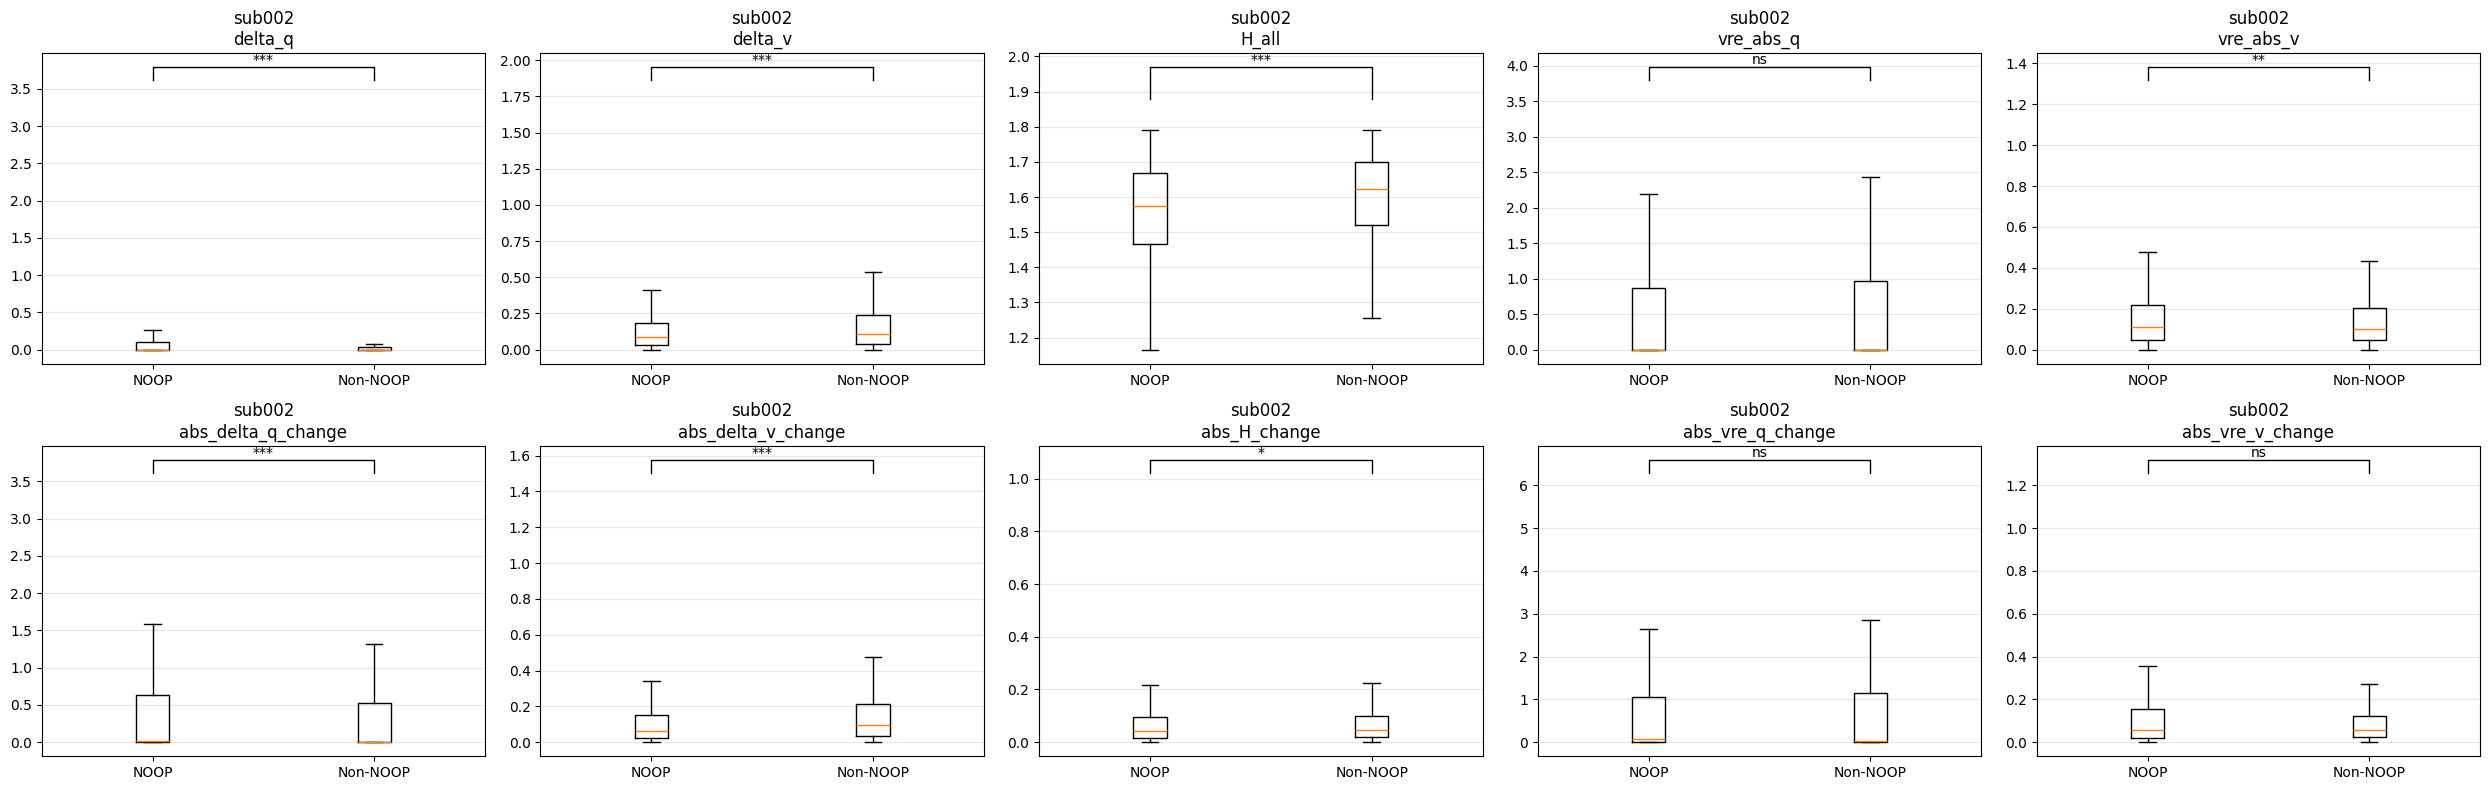

In [5]:
import re
from pathlib import Path
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ====== 설정 ======
BASE_DIR = Path("./test")
FILE_GLOB = "*.npy"

# ---- 필터링 옵션 (None이면 전체 포함) ----
FILTER_SUB = 'sub002'       # 예: "sub002"
FILTER_SES = '03'        # 예: "03" 또는 "3"
FILTER_BLOCK = None      # 예: "7"
FILTER_GAME = None       # 예: "2"
FILTER_SUFFIX = None     # 예: "000"

# 어떤 레벨을 출력할지 (True면 통계 출력 + 플롯 출력)
SHOW_FILE_LEVEL = False
SHOW_SESSION_BLOCK_LEVEL = False
SHOW_SESSION_LEVEL = False
SHOW_SUBJECT_LEVEL = True

# ====== 유틸 ======
def sig_label(p):
    if not np.isfinite(p):
        return "ns"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def top2_gap(mat):
    if mat.shape[1] < 2:
        return np.full(mat.shape[0], np.nan)
    part = np.partition(mat, -2, axis=1)[:, -2:]
    return part.max(axis=1) - part.min(axis=1)

def top2_gap_1d(vals):
    if len(vals) < 2:
        return np.nan
    part = np.partition(vals, -2)[-2:]
    return part.max() - part.min()

def parse_meta(path: Path):
    """
    path 예: test/sub002/ses-03/sub002-ses03-block7-game2_000.npy
    """
    sub = path.parts[-3] if len(path.parts) >= 3 else None  # sub002
    ses_folder = path.parts[-2] if len(path.parts) >= 2 else None  # ses-03

    base = path.stem  # sub002-ses03-block7-game2_000
    def grab(pattern):
        m = re.search(pattern, base)
        return m.group(1) if m else None

    sub_in = grab(r"(sub\d+)")
    ses_in = grab(r"ses(\d+)")
    block_in = grab(r"block(\d+)")
    game_in = grab(r"game(\d+)")
    suffix_in = grab(r"_(\d+)$")

    if not sub_in and sub and re.match(r"sub\d+", sub):
        sub_in = sub
    if not ses_in and ses_folder and re.match(r"ses-\d+", ses_folder):
        ses_in = ses_folder.replace("ses-", "")

    return {
        "sub": sub_in,          # "sub002"
        "ses": ses_in,          # "03"
        "block": block_in,      # "7"
        "game": game_in,        # "2"
        "suffix": suffix_in,    # "000"
        "file": str(path),
        "basename": path.name,
    }

def match_filter(val, flt):
    if flt is None:
        return True
    if val is None:
        return False
    return str(val).lstrip("0") == str(flt).lstrip("0")

def passes_filters(meta):
    return (
        (FILTER_SUB is None or meta["sub"] == FILTER_SUB) and
        match_filter(meta["ses"], FILTER_SES) and
        match_filter(meta["block"], FILTER_BLOCK) and
        match_filter(meta["game"], FILTER_GAME) and
        match_filter(meta["suffix"], FILTER_SUFFIX)
    )

def compute_metrics(data):
    tree = data["tree_reps"]

    q_key = "cur_qs_mean"
    v_key = "cur_v"
    root_q_key = "root_qs_mean"

    status = np.asarray(data["status"])

    if "human_action" in data:
        action_raw = np.asarray(data["human_action"])
    else:
        action_raw = np.asarray(data["thinker_action"])
    if action_raw.ndim == 1:
        action_ids = action_raw.astype(int)
    else:
        action_ids = np.argmax(action_raw, axis=1)

    q_all = np.asarray(tree[q_key])
    v_all = np.asarray(tree[v_key]).reshape(-1)
    root_qs = np.asarray(tree[root_q_key]) if root_q_key in tree else None
    root_v_all = np.asarray(tree["root_v"]).reshape(-1) if "root_v" in tree else None

    actor_policy = np.asarray(data["actor_policy"]) if "actor_policy" in data else None
    if actor_policy is None:
        logits_all = None
    elif actor_policy.ndim >= 2:
        logits_all = actor_policy.reshape(actor_policy.shape[0], -1)
    else:
        logits_all = actor_policy

    num_actions = q_all.shape[1]

    real_all = np.where(status == 0)[0]
    imag2_indices = np.where(status == 2)[0]

    prev_imag_all = np.full(real_all.shape[0], -1, dtype=int)
    j = 0
    for i, r in enumerate(real_all):
        while j < len(imag2_indices) and imag2_indices[j] < r:
            j += 1
        prev_imag_all[i] = imag2_indices[j - 1] if j > 0 else -1

    pos_all = np.arange(len(real_all))
    pos_in_real = pos_all[1:]
    real_indices = real_all[pos_in_real]
    prev_imag = prev_imag_all[pos_in_real]

    valid = prev_imag >= 0
    pos_in_real = pos_in_real[valid]
    real_indices = real_indices[valid]
    prev_imag = prev_imag[valid]

    real_actions = action_ids[real_indices]
    noop_mask = real_actions == 0
    nonnoop_mask = ~noop_mask

    Q_prev = q_all[prev_imag]
    V_prev = v_all[prev_imag]
    logits_prev = logits_all[prev_imag] if logits_all is not None else None

    delta_q = top2_gap(Q_prev)

    if "cur_action" in tree:
        cur_action = np.asarray(tree["cur_action"])
        if cur_action.ndim == 2 and cur_action.shape[1] == num_actions:
            cur_action_id = np.argmax(cur_action, axis=1)
        else:
            cur_action_id = cur_action.astype(int).reshape(-1)
    else:
        cur_action_id = None

    delta_v = np.full(len(pos_in_real), np.nan, dtype=float)
    vre_abs_v = np.full(len(pos_in_real), np.nan, dtype=float)

    if cur_action_id is not None:
        for i, pos in enumerate(pos_in_real):
            prev_real_idx = real_all[pos - 1]
            last_imag_idx = prev_imag[i]
            if last_imag_idx <= prev_real_idx:
                continue

            idx_range = np.arange(prev_real_idx + 1, last_imag_idx + 1)
            if len(idx_range) == 0:
                continue

            prev_status = status[idx_range - 1]
            mask = (status[idx_range] == 2) & ((prev_status == 0) | (prev_status == 1))
            sel_idx = idx_range[mask]
            if len(sel_idx) == 0:
                continue

            action_means = []
            action_mean_map = {}
            for a in range(num_actions):
                mask_a = cur_action_id[sel_idx] == a
                if np.any(mask_a):
                    mean_v = np.mean(v_all[sel_idx[mask_a]])
                    action_means.append(mean_v)
                    action_mean_map[a] = mean_v

            if len(action_means) >= 2:
                delta_v[i] = top2_gap_1d(np.array(action_means))

            if root_v_all is not None:
                ra = real_actions[i]
                if ra in action_mean_map:
                    vre_abs_v[i] = np.abs(action_mean_map[ra] - root_v_all[real_indices[i]])

    if logits_prev is not None:
        logits_shift = logits_prev - np.max(logits_prev, axis=1, keepdims=True)
        pi_prev = np.exp(logits_shift)
        pi_prev = pi_prev / np.sum(pi_prev, axis=1, keepdims=True)
        H_all = -np.nansum(pi_prev * np.log(pi_prev + 1e-12), axis=1)
        p_noop = pi_prev[:, 0]
    else:
        H_all = np.full(len(pos_in_real), np.nan, dtype=float)
        p_noop = np.full(len(pos_in_real), np.nan, dtype=float)

    next_real = np.full(pos_in_real.shape[0], -1, dtype=int)
    valid_next = (pos_in_real + 1) < len(real_all)
    next_real[valid_next] = real_all[pos_in_real[valid_next] + 1]

    vre = np.full(pos_in_real.shape[0], np.nan, dtype=float)
    if root_qs is not None:
        for i in range(len(pos_in_real)):
            nr = next_real[i]
            if nr >= 0:
                a = real_actions[i]
                vre[i] = Q_prev[i, a] - root_qs[nr, a]
    else:
        for i in range(len(pos_in_real)):
            nr = next_real[i]
            if nr >= 0:
                a = real_actions[i]
                vre[i] = Q_prev[i, a] - q_all[nr, a]

    vre_abs_q = np.abs(vre)

    metrics = {
        "delta_q": delta_q,
        "delta_v": delta_v,
        "H_all": H_all,
        "p_noop": p_noop,
        "V_prev(cur_v)": V_prev,
        "vre": vre,
        "vre_abs_q": vre_abs_q,
        "vre_abs_v": vre_abs_v,
    }

    # ---- 전후 변화(절댓값) ----
    n_real = len(real_all)
    delta_q_by_pos = np.full(n_real, np.nan)
    delta_v_by_pos = np.full(n_real, np.nan)
    H_by_pos = np.full(n_real, np.nan)
    vre_by_pos = np.full(n_real, np.nan)
    vre_v_by_pos = np.full(n_real, np.nan)

    delta_q_by_pos[pos_in_real] = delta_q
    delta_v_by_pos[pos_in_real] = delta_v
    H_by_pos[pos_in_real] = H_all
    vre_by_pos[pos_in_real] = vre
    vre_v_by_pos[pos_in_real] = vre_abs_v

    next_pos = pos_in_real + 1
    valid_diff = next_pos < n_real

    diff_delta_q = np.full(pos_in_real.shape[0], np.nan)
    diff_delta_v = np.full(pos_in_real.shape[0], np.nan)
    diff_H = np.full(pos_in_real.shape[0], np.nan)
    diff_vre_q = np.full(pos_in_real.shape[0], np.nan)
    diff_vre_v = np.full(pos_in_real.shape[0], np.nan)

    pos_valid = pos_in_real[valid_diff]
    next_valid = next_pos[valid_diff]

    mask_q = np.isfinite(delta_q_by_pos[pos_valid]) & np.isfinite(delta_q_by_pos[next_valid])
    mask_vv = np.isfinite(delta_v_by_pos[pos_valid]) & np.isfinite(delta_v_by_pos[next_valid])
    mask_H = np.isfinite(H_by_pos[pos_valid]) & np.isfinite(H_by_pos[next_valid])
    mask_vre_q = np.isfinite(vre_by_pos[pos_valid]) & np.isfinite(vre_by_pos[next_valid])
    mask_vre_v = np.isfinite(vre_v_by_pos[pos_valid]) & np.isfinite(vre_v_by_pos[next_valid])

    diff_delta_q[np.where(valid_diff)[0][mask_q]] = np.abs(
        delta_q_by_pos[pos_valid[mask_q]] - delta_q_by_pos[next_valid[mask_q]]
    )
    diff_delta_v[np.where(valid_diff)[0][mask_vv]] = np.abs(
        delta_v_by_pos[pos_valid[mask_vv]] - delta_v_by_pos[next_valid[mask_vv]]
    )
    diff_H[np.where(valid_diff)[0][mask_H]] = np.abs(
        H_by_pos[pos_valid[mask_H]] - H_by_pos[next_valid[mask_H]]
    )
    diff_vre_q[np.where(valid_diff)[0][mask_vre_q]] = np.abs(
        vre_by_pos[pos_valid[mask_vre_q]] - vre_by_pos[next_valid[mask_vre_q]]
    )
    diff_vre_v[np.where(valid_diff)[0][mask_vre_v]] = np.abs(
        vre_v_by_pos[pos_valid[mask_vre_v]] - vre_v_by_pos[next_valid[mask_vre_v]]
    )

    metrics.update({
        "abs_delta_q_change": diff_delta_q,
        "abs_delta_v_change": diff_delta_v,
        "abs_H_change": diff_H,
        "abs_vre_q_change": diff_vre_q,
        "abs_vre_v_change": diff_vre_v,
    })

    return metrics, noop_mask, nonnoop_mask

def summarize_arrays(name, a, b):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    print(f"\n[{name}]")
    print(f"  NOOP:    n={len(a)} mean={np.mean(a):.4f} std={np.std(a):.4f}")
    print(f"  NonNOOP: n={len(b)} mean={np.mean(b):.4f} std={np.std(b):.4f}")
    p = np.nan
    if len(a) > 1 and len(b) > 1:
        _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        print(f"  Mann-Whitney U p={p:.3g} ({sig_label(p)})")
    return p

def boxplot_metrics(group_name, metrics_store, pvals_store):
    plot_names = [
        "delta_q", "delta_v", "H_all", "vre_abs_q", "vre_abs_v",
        "abs_delta_q_change", "abs_delta_v_change", "abs_H_change",
        "abs_vre_q_change", "abs_vre_v_change",
    ]
    fig, axes = plt.subplots(2, 5, figsize=(5 * 5, 4 * 2))
    axes = axes.flatten()

    for ax, name in zip(axes, plot_names):
        if name not in metrics_store:
            ax.axis("off")
            continue
        a = metrics_store[name]["noop"]
        b = metrics_store[name]["nonnoop"]
        ax.boxplot([a, b], labels=["NOOP", "Non-NOOP"], showfliers=False)
        ax.set_title(f"{group_name}\n{name}")
        ax.grid(axis="y", alpha=0.3)

        p = pvals_store.get(name, np.nan)
        sig = sig_label(p)
        if len(a) > 0 and len(b) > 0 and np.isfinite(p):
            y_max = np.nanmax(np.concatenate([a, b]))
            y = y_max + (0.05 * y_max if y_max != 0 else 0.05)
            h = (0.05 * y_max if y_max != 0 else 0.05)
            ax.plot([1, 1, 2, 2], [y, y + h, y + h, y], lw=1.0, c="black")
            ax.text(1.5, y + h, sig, ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

# ====== 파일 로드 (subXXX 폴더만 스캔) ======
sub_dirs = [
    d for d in BASE_DIR.iterdir()
    if d.is_dir() and re.fullmatch(r"sub\d+", d.name)
]

files = []
for sd in sub_dirs:
    files.extend(sd.rglob(FILE_GLOB))

files = sorted(files)
print(f"Found {len(files)} files under {BASE_DIR} (subXXX only)")

records = []
for f in files:
    meta = parse_meta(f)
    if not passes_filters(meta):
        continue
    data = np.load(f, allow_pickle=True).item()
    metrics, noop_mask, nonnoop_mask = compute_metrics(data)
    records.append({
        "path": f,
        "meta": meta,
        "metrics": metrics,
        "noop_mask": noop_mask,
        "nonnoop_mask": nonnoop_mask,
    })

print(f"After filter: {len(records)} files")

# ====== 그룹 집계 ======
def init_group_store():
    return {}

def add_to_group(store, group_key, metrics, noop_mask, nonnoop_mask):
    if group_key not in store:
        store[group_key] = {}
    for name, arr in metrics.items():
        if name not in store[group_key]:
            store[group_key][name] = {"noop": [], "nonnoop": []}
        store[group_key][name]["noop"].append(arr[noop_mask & np.isfinite(arr)])
        store[group_key][name]["nonnoop"].append(arr[nonnoop_mask & np.isfinite(arr)])

def finalize_group(store):
    out = {}
    for g, md in store.items():
        out[g] = {}
        for name, parts in md.items():
            a = np.concatenate(parts["noop"]) if len(parts["noop"]) else np.array([])
            b = np.concatenate(parts["nonnoop"]) if len(parts["nonnoop"]) else np.array([])
            out[g][name] = {"noop": a, "nonnoop": b}
    return out

file_store = init_group_store()
sess_block_store = init_group_store()
sess_store = init_group_store()
sub_store = init_group_store()

for r in records:
    m = r["meta"]
    metrics = r["metrics"]
    noop_mask = r["noop_mask"]
    nonnoop_mask = r["nonnoop_mask"]

    file_key = m["basename"]
    sb_key = f"{m['sub']}_ses{m['ses']}_block{m['block']}"
    s_key = f"{m['sub']}_ses{m['ses']}"
    sub_key = f"{m['sub']}"

    add_to_group(file_store, file_key, metrics, noop_mask, nonnoop_mask)
    add_to_group(sess_block_store, sb_key, metrics, noop_mask, nonnoop_mask)
    add_to_group(sess_store, s_key, metrics, noop_mask, nonnoop_mask)
    add_to_group(sub_store, sub_key, metrics, noop_mask, nonnoop_mask)

file_store = finalize_group(file_store)
sess_block_store = finalize_group(sess_block_store)
sess_store = finalize_group(sess_store)
sub_store = finalize_group(sub_store)

# ====== 출력 ======
if SHOW_FILE_LEVEL:
    for g, metrics_store in file_store.items():
        print(f"\n== FILE: {g} ==")
        pvals = {}
        for name, arrs in metrics_store.items():
            pvals[name] = summarize_arrays(name, arrs["noop"], arrs["nonnoop"])
        boxplot_metrics(g, metrics_store, pvals)

if SHOW_SESSION_BLOCK_LEVEL:
    for g, metrics_store in sess_block_store.items():
        print(f"\n== SES-BLOCK: {g} ==")
        pvals = {}
        for name, arrs in metrics_store.items():
            pvals[name] = summarize_arrays(name, arrs["noop"], arrs["nonnoop"])
        boxplot_metrics(g, metrics_store, pvals)

if SHOW_SESSION_LEVEL:
    for g, metrics_store in sess_store.items():
        print(f"\n== SESSION: {g} ==")
        pvals = {}
        for name, arrs in metrics_store.items():
            pvals[name] = summarize_arrays(name, arrs["noop"], arrs["nonnoop"])
        boxplot_metrics(g, metrics_store, pvals)

if SHOW_SUBJECT_LEVEL:
    for g, metrics_store in sub_store.items():
        print(f"\n== SUBJECT: {g} ==")
        pvals = {}
        for name, arrs in metrics_store.items():
            pvals[name] = summarize_arrays(name, arrs["noop"], arrs["nonnoop"])
        boxplot_metrics(g, metrics_store, pvals)


Found 3 files under test (subXXX only)

[SUBJECT: sub002] usable rows=17876 cols=8
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                17876
Model:                          Logit   Df Residuals:                    17867
Method:                           MLE   Df Model:                            8
Date:                Fri, 30 Jan 2026   Pseudo R-squ.:                  0.1206
Time:                        14:31:34   Log-Likelihood:                -10598.
converged:                       True   LL-Null:                       -12052.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.4229      0.017     24.788      0.000       0.389       0.456
delta_q          -0.0167      0.016    

,coef,p
p_noop,0.944029,0.000000e+00
const,0.422912,1.212953e-135
V_prev(cur_v),-0.240813,8.903990e-42
vre_abs_v,0.233217,1.044851e-38
delta_v,-0.208831,6.216474e-33
vre_abs_q,-0.131392,1.731289e-10
vre,0.080660,6.537251e-05
H_all,-0.070617,4.490434e-04
delta_q,-0.016696,3.062104e-01



Significant features (p<0.05):


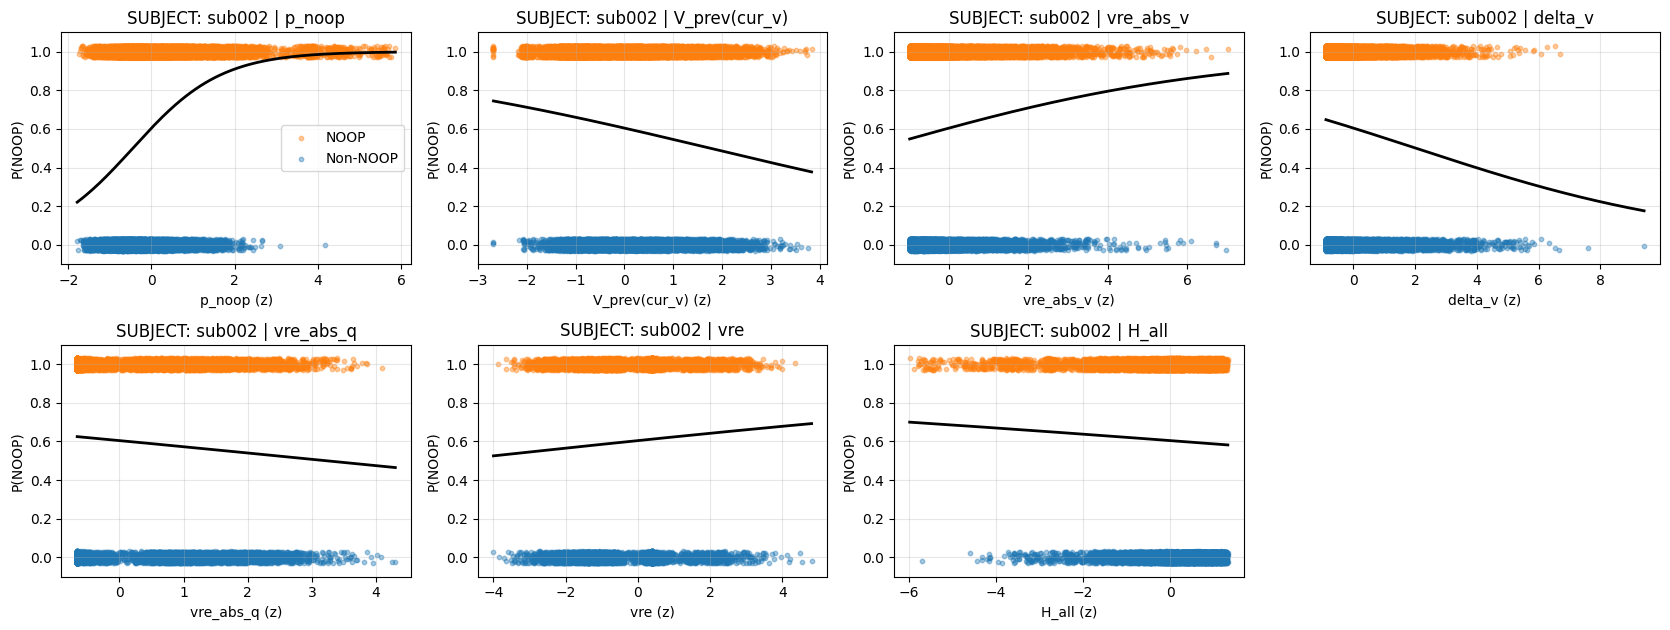

,coef,p
p_noop,0.944029,0.000000e+00
V_prev(cur_v),-0.240813,8.903990e-42
vre_abs_v,0.233217,1.044851e-38
delta_v,-0.208831,6.216474e-33
vre_abs_q,-0.131392,1.731289e-10
vre,0.080660,6.537251e-05
H_all,-0.070617,4.490434e-04


In [12]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ====== 설정 ======
BASE_DIR = Path("./test")
FILE_GLOB = "*.npy"

# ---- 필터링 옵션 (None이면 전체 포함) ----
FILTER_SUB = "sub002 "  # 예: "sub002"  (공백 있어도 자동 정리)
FILTER_SES = "03"       # 예: "03" 또는 "3"
FILTER_BLOCK = None     # 예: "7"
FILTER_GAME = None      # 예: "2"
FILTER_SUFFIX = None    # 예: "000"

# 어떤 레벨을 회귀할지
RUN_FILE_LEVEL = False
RUN_SESSION_BLOCK_LEVEL = False
RUN_SESSION_LEVEL = False
RUN_SUBJECT_LEVEL = True

# (선택) root_action vs human_action mismatch 출력
CHECK_MISMATCH = False

# ====== 유틸 ======
def _clean(x):
    return None if x is None else str(x).strip()

FILTER_SUB = _clean(FILTER_SUB)
FILTER_SES = _clean(FILTER_SES)
FILTER_BLOCK = _clean(FILTER_BLOCK)
FILTER_GAME = _clean(FILTER_GAME)
FILTER_SUFFIX = _clean(FILTER_SUFFIX)

def parse_meta(path: Path):
    """
    path 예: test/sub002/ses-03/sub002-ses03-block7-game2_000.npy
    """
    sub = path.parts[-3] if len(path.parts) >= 3 else None
    ses_folder = path.parts[-2] if len(path.parts) >= 2 else None

    base = path.stem
    def grab(pattern):
        m = re.search(pattern, base)
        return m.group(1) if m else None

    sub_in = grab(r"(sub\d+)")
    ses_in = grab(r"ses(\d+)")
    block_in = grab(r"block(\d+)")
    game_in = grab(r"game(\d+)")
    suffix_in = grab(r"_(\d+)$")

    if not sub_in and sub and re.match(r"sub\d+", sub):
        sub_in = sub
    if not ses_in and ses_folder and re.match(r"ses-\d+", ses_folder):
        ses_in = ses_folder.replace("ses-", "")

    return {
        "sub": sub_in,
        "ses": ses_in,
        "block": block_in,
        "game": game_in,
        "suffix": suffix_in,
        "file": str(path),
        "basename": path.name,
    }

def match_filter(val, flt):
    if flt is None:
        return True
    if val is None:
        return False
    return str(val).lstrip("0") == str(flt).lstrip("0")

def passes_filters(meta):
    return (
        (FILTER_SUB is None or meta["sub"] == FILTER_SUB) and
        match_filter(meta["ses"], FILTER_SES) and
        match_filter(meta["block"], FILTER_BLOCK) and
        match_filter(meta["game"], FILTER_GAME) and
        match_filter(meta["suffix"], FILTER_SUFFIX)
    )

def top2_gap(mat):
    if mat.shape[1] < 2:
        return np.full(mat.shape[0], np.nan)
    part = np.partition(mat, -2, axis=1)[:, -2:]
    return part.max(axis=1) - part.min(axis=1)

def top2_gap_1d(vals):
    if len(vals) < 2:
        return np.nan
    part = np.partition(vals, -2)[-2:]
    return part.max() - part.min()

def build_noop_df_and_y(data):
    """
    파일 하나에서 decision-time feature df + human NOOP 라벨 y 생성
    """
    tree = data["tree_reps"]

    # --- human action ---
    human_action_oh = np.asarray(data["human_action"])
    if human_action_oh.ndim == 2:
        human_action = np.argmax(human_action_oh, axis=1)
        human_valid = human_action_oh.sum(axis=1) > 0
    else:
        human_action = human_action_oh.astype(int)
        human_valid = human_action >= 0

    status = np.asarray(data["status"])
    q_all = np.asarray(tree["cur_qs_mean"])
    v_all = np.asarray(tree["cur_v"]).reshape(-1)
    root_qs = np.asarray(tree["root_qs_mean"]) if "root_qs_mean" in tree else None
    root_v_all = np.asarray(tree["root_v"]).reshape(-1) if "root_v" in tree else None

    actor_policy = np.asarray(data["actor_policy"]) if "actor_policy" in data else None
    if actor_policy is None:
        logits_all = None
    elif actor_policy.ndim >= 2:
        logits_all = actor_policy.reshape(actor_policy.shape[0], -1)
    else:
        logits_all = actor_policy

    num_actions = q_all.shape[1]

    # real / imag2 매칭
    real_all = np.where(status == 0)[0]
    imag2_indices = np.where(status == 2)[0]

    prev_imag_all = np.full(real_all.shape[0], -1, dtype=int)
    j = 0
    for i, r in enumerate(real_all):
        while j < len(imag2_indices) and imag2_indices[j] < r:
            j += 1
        prev_imag_all[i] = imag2_indices[j - 1] if j > 0 else -1

    pos_all = np.arange(len(real_all))
    pos_in_real = pos_all[1:]
    real_indices = real_all[pos_in_real]
    prev_imag = prev_imag_all[pos_in_real]

    valid = prev_imag >= 0
    pos_in_real = pos_in_real[valid]
    real_indices = real_indices[valid]
    prev_imag = prev_imag[valid]

    # (선택) root_action vs human_action 체크
    if CHECK_MISMATCH and "root_action" in tree:
        root_action_real = np.asarray(tree["root_action"])[real_indices]
        if root_action_real.ndim == 2:
            root_action_real = np.argmax(root_action_real, axis=1)
        mismatch_rate = np.mean(root_action_real != human_action[real_indices])
        print(f"[check] root_action vs human_action mismatch rate: {mismatch_rate:.3f}")

    # y (human 기준 NOOP)
    y = (human_action[real_indices] == 0).astype(float)
    valid_h = human_valid[real_indices]

    # --- feature 생성 (decision-time) ---
    Q_prev = q_all[prev_imag]
    V_prev = v_all[prev_imag]
    logits_prev = logits_all[prev_imag] if logits_all is not None else None

    delta_q = top2_gap(Q_prev)

    # delta_v, vre_abs_v
    if "cur_action" in tree:
        cur_action = np.asarray(tree["cur_action"])
        if cur_action.ndim == 2 and cur_action.shape[1] == num_actions:
            cur_action_id = np.argmax(cur_action, axis=1)
        else:
            cur_action_id = cur_action.astype(int).reshape(-1)
    else:
        cur_action_id = None

    delta_v = np.full(len(pos_in_real), np.nan, dtype=float)
    vre_abs_v = np.full(len(pos_in_real), np.nan, dtype=float)

    if cur_action_id is not None:
        for i, pos in enumerate(pos_in_real):
            prev_real_idx = real_all[pos - 1]
            last_imag_idx = prev_imag[i]
            if last_imag_idx <= prev_real_idx:
                continue

            idx_range = np.arange(prev_real_idx + 1, last_imag_idx + 1)
            if len(idx_range) == 0:
                continue

            prev_status = status[idx_range - 1]
            mask = (status[idx_range] == 2) & ((prev_status == 0) | (prev_status == 1))
            sel_idx = idx_range[mask]
            if len(sel_idx) == 0:
                continue

            action_means = []
            action_mean_map = {}
            for a in range(num_actions):
                mask_a = cur_action_id[sel_idx] == a
                if np.any(mask_a):
                    mean_v = np.mean(v_all[sel_idx[mask_a]])
                    action_means.append(mean_v)
                    action_mean_map[a] = mean_v

            if len(action_means) >= 2:
                delta_v[i] = top2_gap_1d(np.array(action_means))

            if root_v_all is not None:
                ra = human_action[real_indices[i]]
                if ra in action_mean_map:
                    vre_abs_v[i] = np.abs(action_mean_map[ra] - root_v_all[real_indices[i]])

    # 정책 엔트로피
    if logits_prev is not None:
        logits_shift = logits_prev - np.max(logits_prev, axis=1, keepdims=True)
        pi_prev = np.exp(logits_shift)
        pi_prev = pi_prev / np.sum(pi_prev, axis=1, keepdims=True)
        H_all = -np.nansum(pi_prev * np.log(pi_prev + 1e-12), axis=1)
        p_noop = pi_prev[:, 0]
    else:
        H_all = np.full(len(pos_in_real), np.nan, dtype=float)
        p_noop = np.full(len(pos_in_real), np.nan, dtype=float)

    # VRE
    next_real = np.full(pos_in_real.shape[0], -1, dtype=int)
    valid_next = (pos_in_real + 1) < len(real_all)
    next_real[valid_next] = real_all[pos_in_real[valid_next] + 1]

    vre = np.full(pos_in_real.shape[0], np.nan, dtype=float)
    if root_qs is not None:
        for i in range(len(pos_in_real)):
            nr = next_real[i]
            if nr >= 0:
                a = human_action[real_indices[i]]
                vre[i] = Q_prev[i, a] - root_qs[nr, a]
    else:
        for i in range(len(pos_in_real)):
            nr = next_real[i]
            if nr >= 0:
                a = human_action[real_indices[i]]
                vre[i] = Q_prev[i, a] - q_all[nr, a]

    vre_abs_q = np.abs(vre)

    metrics = {
        "delta_q": delta_q,
        "delta_v": delta_v,
        "H_all": H_all,
        "p_noop": p_noop,
        "V_prev(cur_v)": V_prev,
        "vre": vre,
        "vre_abs_q": vre_abs_q,
        "vre_abs_v": vre_abs_v,
    }

    df = pd.DataFrame(metrics)
    return df, y, valid_h


def plot_sig_logit(Xz_vif, y, params, sig_features, title_prefix=""):
    if len(sig_features) == 0:
        print("No significant features to plot.")
        return

    rng = np.random.default_rng(0)
    n = len(sig_features)
    ncols = 4  # 세로(행) 4개 고정
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, feat in enumerate(sig_features):
        ax = axes[i]
        if feat not in Xz_vif.columns:
            ax.axis("off")
            continue

        x = Xz_vif[feat].values
        yj = y + (rng.random(len(y)) - 0.5) * 0.06

        mask_noop = y == 1
        mask_non = y == 0

        ax.scatter(x[mask_noop], yj[mask_noop], s=10, alpha=0.4, c="tab:orange", label="NOOP")
        ax.scatter(x[mask_non], yj[mask_non], s=10, alpha=0.4, c="tab:blue", label="Non-NOOP")

        x_grid = np.linspace(np.nanmin(x), np.nanmax(x), 200)
        b0 = params["const"] if "const" in params else 0.0
        b1 = params[feat] if feat in params else 0.0
        p = 1 / (1 + np.exp(-(b0 + b1 * x_grid)))

        ax.plot(x_grid, p, color="black", lw=2)
        ax.set_ylim(-0.1, 1.1)
        ax.set_xlabel(f"{feat} (z)")
        ax.set_ylabel("P(NOOP)")
        ax.set_title(f"{title_prefix}{feat}")
        ax.grid(alpha=0.3)

        if i == 0:
            ax.legend()

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()




# ---- VIF 제거 + 회귀 ----
def run_noop_logit(df, y, title=""):
    # X/y 정리
    X = df.copy()
    X = X.replace([np.inf, -np.inf], np.nan)

    # 전부 NaN 열 제거
    all_nan = X.isna().all()
    X = X.loc[:, ~all_nan]

    # 분산 0 제거
    nunique = X.nunique(dropna=True)
    X = X.loc[:, nunique > 1]

    # 표준화
    mean = X.mean()
    std = X.std(ddof=0)
    good_cols = std > 0
    X = X.loc[:, good_cols]
    Xz = (X - mean[good_cols]) / std[good_cols]

    # 유효 행
    mask = np.isfinite(Xz).all(axis=1) & np.isfinite(y)
    Xz = Xz[mask].reset_index(drop=True)
    y = y[mask]

    print(f"\n[{title}] usable rows={len(y)} cols={Xz.shape[1]}")
    if len(y) == 0 or Xz.shape[1] == 0:
        print(" -> skip (no usable data)")
        return

    # VIF 제거
    vif_thresh = 5.0
    def compute_vif(df_):
        vifs = []
        for i in range(df_.shape[1]):
            vifs.append(variance_inflation_factor(df_.values, i))
        return pd.Series(vifs, index=df_.columns)

    Xz_vif = Xz.copy()
    while True:
        vifs = compute_vif(Xz_vif)
        max_vif = vifs.max()
        if max_vif <= vif_thresh:
            break
        drop_col = vifs.idxmax()
        print(f"Dropping '{drop_col}' with VIF={max_vif:.2f}")
        Xz_vif = Xz_vif.drop(columns=[drop_col])

    Xz_vif_const = sm.add_constant(Xz_vif, has_constant="add")

    # Logit + robust (fallback to GLM)
    try:
        model = sm.Logit(y, Xz_vif_const).fit(disp=False)
        if hasattr(model, "get_robustcov_results"):
            rob = model.get_robustcov_results(cov_type="HC1")
        else:
            rob = model
    except Exception as e:
        print("Logit failed -> GLM(Binomial) fallback:", e)
        rob = sm.GLM(y, Xz_vif_const, family=sm.families.Binomial()).fit(cov_type="HC1")

    print(rob.summary())

    coef = pd.DataFrame({
        "coef": rob.params,
        "p": rob.pvalues
    }).sort_values("p")
    display(coef)

    sig = coef[(coef["p"] < 0.05) & (coef.index != "const")]
    print("\nSignificant features (p<0.05):")
    sig_feats = [f for f in sig.index if f != "const"]
    plot_sig_logit(Xz_vif, y, rob.params, sig_feats, title_prefix=f"{title} | ")
    display(sig)
    


# ====== 파일 로드 (subXXX만 스캔) ======
sub_dirs = [
    d for d in BASE_DIR.iterdir()
    if d.is_dir() and re.fullmatch(r"sub\d+", d.name)
]

files = []
for sd in sub_dirs:
    files.extend(sd.rglob(FILE_GLOB))
files = sorted(files)
print(f"Found {len(files)} files under {BASE_DIR} (subXXX only)")

# ====== 그룹 집계 ======
groups = {
    "file": {},
    "session_block": {},
    "session": {},
    "subject": {},
}

def add_group(store, key, df, y, valid_h):
    if key not in store:
        store[key] = {"dfs": [], "ys": []}
    store[key]["dfs"].append(df.loc[valid_h].reset_index(drop=True))
    store[key]["ys"].append(y[valid_h])

for f in files:
    meta = parse_meta(f)
    if not passes_filters(meta):
        continue

    data = np.load(f, allow_pickle=True).item()
    df, y, valid_h = build_noop_df_and_y(data)

    file_key = meta["basename"]
    sb_key = f"{meta['sub']}_ses{meta['ses']}_block{meta['block']}"
    s_key = f"{meta['sub']}_ses{meta['ses']}"
    sub_key = f"{meta['sub']}"

    add_group(groups["file"], file_key, df, y, valid_h)
    add_group(groups["session_block"], sb_key, df, y, valid_h)
    add_group(groups["session"], s_key, df, y, valid_h)
    add_group(groups["subject"], sub_key, df, y, valid_h)

# ====== 회귀 실행 ======
def run_group_level(store, title_prefix=""):
    for key, bundle in store.items():
        df_all = pd.concat(bundle["dfs"], ignore_index=True) if bundle["dfs"] else None
        y_all = np.concatenate(bundle["ys"]) if bundle["ys"] else None
        if df_all is None or y_all is None:
            continue
        run_noop_logit(df_all, y_all, title=f"{title_prefix}{key}")

if RUN_FILE_LEVEL:
    run_group_level(groups["file"], "FILE: ")

if RUN_SESSION_BLOCK_LEVEL:
    run_group_level(groups["session_block"], "SES-BLOCK: ")

if RUN_SESSION_LEVEL:
    run_group_level(groups["session"], "SESSION: ")

if RUN_SUBJECT_LEVEL:
    run_group_level(groups["subject"], "SUBJECT: ")


Found 3 files under test (subXXX only)

[SUBJECT: sub002] usable rows=17876 cols=7
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 17454.
Model:                      BetaModel   AIC:                        -3.489e+04
Method:            Maximum Likelihood   BIC:                        -3.482e+04
Date:                Fri, 30 Jan 2026                                         
Time:                        14:49:43                                         
No. Observations:               17876                                         
Df Residuals:                   17867                                         
Df Model:                           7                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.1465      0.004   -293

,coef,p
const,-1.146509,0.000000e+00
H_all,-0.202722,0.000000e+00
V_prev(cur_v),-0.061347,6.508524e-49
delta_v,0.036270,6.575206e-21
vre_abs_q,0.040792,1.041138e-17
vre,-0.012135,9.319897e-03
delta_q,0.008538,2.348517e-02
vre_abs_v,0.001886,6.320077e-01



Significant features (p<0.05):


,coef,p
H_all,-0.202722,0.000000e+00
V_prev(cur_v),-0.061347,6.508524e-49
delta_v,0.036270,6.575206e-21
vre_abs_q,0.040792,1.041138e-17
vre,-0.012135,9.319897e-03
delta_q,0.008538,2.348517e-02



[Refit with significant features]
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 17454.
Model:                      BetaModel   AIC:                        -3.489e+04
Method:            Maximum Likelihood   BIC:                        -3.483e+04
Date:                Fri, 30 Jan 2026                                         
Time:                        14:49:43                                         
No. Observations:               17876                                         
Df Residuals:                   17868                                         
Df Model:                           6                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.1465      0.004   -293.479      0.000      -1.154      -1.139
H_all   

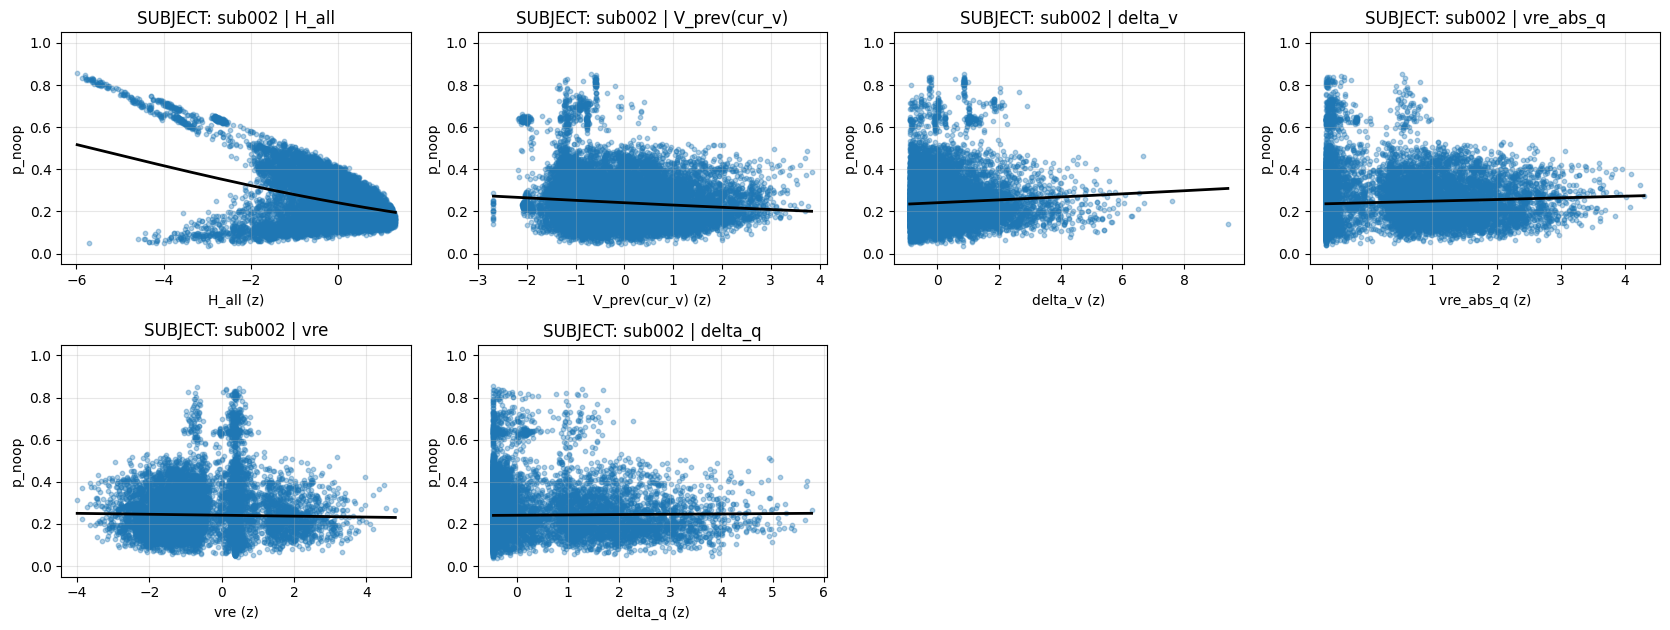

In [22]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.othermod.betareg import BetaModel
import matplotlib.pyplot as plt

# ====== 설정 ======
BASE_DIR = Path("./test")
FILE_GLOB = "*.npy"

# ---- 필터링 옵션 (None이면 전체 포함) ----
FILTER_SUB = "sub002 "  # 예: "sub002"  (공백 있어도 자동 정리)
FILTER_SES = "03"       # 예: "03" 또는 "3"
FILTER_BLOCK = None     # 예: "7"
FILTER_GAME = None      # 예: "2"
FILTER_SUFFIX = None    # 예: "000"

# 어떤 레벨을 회귀할지
RUN_FILE_LEVEL = False
RUN_SESSION_BLOCK_LEVEL = False
RUN_SESSION_LEVEL = False
RUN_SUBJECT_LEVEL = True

# (선택) root_action vs human_action mismatch 출력
CHECK_MISMATCH = False

# ====== 유틸 ======
def _clean(x):
    return None if x is None else str(x).strip()

FILTER_SUB = _clean(FILTER_SUB)
FILTER_SES = _clean(FILTER_SES)
FILTER_BLOCK = _clean(FILTER_BLOCK)
FILTER_GAME = _clean(FILTER_GAME)
FILTER_SUFFIX = _clean(FILTER_SUFFIX)

def parse_meta(path: Path):
    """
    path 예: test/sub002/ses-03/sub002-ses03-block7-game2_000.npy
    """
    sub = path.parts[-3] if len(path.parts) >= 3 else None
    ses_folder = path.parts[-2] if len(path.parts) >= 2 else None

    base = path.stem
    def grab(pattern):
        m = re.search(pattern, base)
        return m.group(1) if m else None

    sub_in = grab(r"(sub\d+)")
    ses_in = grab(r"ses(\d+)")
    block_in = grab(r"block(\d+)")
    game_in = grab(r"game(\d+)")
    suffix_in = grab(r"_(\d+)$")

    if not sub_in and sub and re.match(r"sub\d+", sub):
        sub_in = sub
    if not ses_in and ses_folder and re.match(r"ses-\d+", ses_folder):
        ses_in = ses_folder.replace("ses-", "")

    return {
        "sub": sub_in,
        "ses": ses_in,
        "block": block_in,
        "game": game_in,
        "suffix": suffix_in,
        "file": str(path),
        "basename": path.name,
    }

def match_filter(val, flt):
    if flt is None:
        return True
    if val is None:
        return False
    return str(val).lstrip("0") == str(flt).lstrip("0")

def passes_filters(meta):
    return (
        (FILTER_SUB is None or meta["sub"] == FILTER_SUB) and
        match_filter(meta["ses"], FILTER_SES) and
        match_filter(meta["block"], FILTER_BLOCK) and
        match_filter(meta["game"], FILTER_GAME) and
        match_filter(meta["suffix"], FILTER_SUFFIX)
    )

def top2_gap(mat):
    if mat.shape[1] < 2:
        return np.full(mat.shape[0], np.nan)
    part = np.partition(mat, -2, axis=1)[:, -2:]
    return part.max(axis=1) - part.min(axis=1)

def top2_gap_1d(vals):
    if len(vals) < 2:
        return np.nan
    part = np.partition(vals, -2)[-2:]
    return part.max() - part.min()

def build_feature_df(data):
    """
    파일 하나에서 decision-time feature df 생성 (p_noop 포함)
    """
    tree = data["tree_reps"]

    # --- human action (vre_abs_v 계산용) ---
    human_action_oh = np.asarray(data["human_action"])
    if human_action_oh.ndim == 2:
        human_action = np.argmax(human_action_oh, axis=1)
        human_valid = human_action_oh.sum(axis=1) > 0
    else:
        human_action = human_action_oh.astype(int)
        human_valid = human_action >= 0

    status = np.asarray(data["status"])
    q_all = np.asarray(tree["cur_qs_mean"])
    v_all = np.asarray(tree["cur_v"]).reshape(-1)
    root_qs = np.asarray(tree["root_qs_mean"]) if "root_qs_mean" in tree else None
    root_v_all = np.asarray(tree["root_v"]).reshape(-1) if "root_v" in tree else None

    actor_policy = np.asarray(data["actor_policy"]) if "actor_policy" in data else None
    if actor_policy is None:
        logits_all = None
    elif actor_policy.ndim >= 2:
        logits_all = actor_policy.reshape(actor_policy.shape[0], -1)
    else:
        logits_all = actor_policy

    num_actions = q_all.shape[1]

    # real / imag2 매칭
    real_all = np.where(status == 0)[0]
    imag2_indices = np.where(status == 2)[0]

    prev_imag_all = np.full(real_all.shape[0], -1, dtype=int)
    j = 0
    for i, r in enumerate(real_all):
        while j < len(imag2_indices) and imag2_indices[j] < r:
            j += 1
        prev_imag_all[i] = imag2_indices[j - 1] if j > 0 else -1

    pos_all = np.arange(len(real_all))
    pos_in_real = pos_all[1:]
    real_indices = real_all[pos_in_real]
    prev_imag = prev_imag_all[pos_in_real]

    valid = prev_imag >= 0
    pos_in_real = pos_in_real[valid]
    real_indices = real_indices[valid]
    prev_imag = prev_imag[valid]

    # (선택) root_action vs human_action 체크
    if CHECK_MISMATCH and "root_action" in tree:
        root_action_real = np.asarray(tree["root_action"])[real_indices]
        if root_action_real.ndim == 2:
            root_action_real = np.argmax(root_action_real, axis=1)
        mismatch_rate = np.mean(root_action_real != human_action[real_indices])
        print(f"[check] root_action vs human_action mismatch rate: {mismatch_rate:.3f}")

    # valid mask (human 기준)
    valid_h = human_valid[real_indices]

    # --- feature 생성 (decision-time) ---
    Q_prev = q_all[prev_imag]
    V_prev = v_all[prev_imag]
    logits_prev = logits_all[prev_imag] if logits_all is not None else None

    delta_q = top2_gap(Q_prev)

    # delta_v, vre_abs_v
    if "cur_action" in tree:
        cur_action = np.asarray(tree["cur_action"])
        if cur_action.ndim == 2 and cur_action.shape[1] == num_actions:
            cur_action_id = np.argmax(cur_action, axis=1)
        else:
            cur_action_id = cur_action.astype(int).reshape(-1)
    else:
        cur_action_id = None

    delta_v = np.full(len(pos_in_real), np.nan, dtype=float)
    vre_abs_v = np.full(len(pos_in_real), np.nan, dtype=float)

    if cur_action_id is not None:
        for i, pos in enumerate(pos_in_real):
            prev_real_idx = real_all[pos - 1]
            last_imag_idx = prev_imag[i]
            if last_imag_idx <= prev_real_idx:
                continue

            idx_range = np.arange(prev_real_idx + 1, last_imag_idx + 1)
            if len(idx_range) == 0:
                continue

            prev_status = status[idx_range - 1]
            mask = (status[idx_range] == 2) & ((prev_status == 0) | (prev_status == 1))
            sel_idx = idx_range[mask]
            if len(sel_idx) == 0:
                continue

            action_means = []
            action_mean_map = {}
            for a in range(num_actions):
                mask_a = cur_action_id[sel_idx] == a
                if np.any(mask_a):
                    mean_v = np.mean(v_all[sel_idx[mask_a]])
                    action_means.append(mean_v)
                    action_mean_map[a] = mean_v

            if len(action_means) >= 2:
                delta_v[i] = top2_gap_1d(np.array(action_means))

            if root_v_all is not None:
                ra = human_action[real_indices[i]]
                if ra in action_mean_map:
                    vre_abs_v[i] = np.abs(action_mean_map[ra] - root_v_all[real_indices[i]])

    # 정책 엔트로피
    if logits_prev is not None:
        logits_shift = logits_prev - np.max(logits_prev, axis=1, keepdims=True)
        pi_prev = np.exp(logits_shift)
        pi_prev = pi_prev / np.sum(pi_prev, axis=1, keepdims=True)
        H_all = -np.nansum(pi_prev * np.log(pi_prev + 1e-12), axis=1)
        p_noop = pi_prev[:, 0]
    else:
        H_all = np.full(len(pos_in_real), np.nan, dtype=float)
        p_noop = np.full(len(pos_in_real), np.nan, dtype=float)

    # VRE
    next_real = np.full(pos_in_real.shape[0], -1, dtype=int)
    valid_next = (pos_in_real + 1) < len(real_all)
    next_real[valid_next] = real_all[pos_in_real[valid_next] + 1]

    vre = np.full(pos_in_real.shape[0], np.nan, dtype=float)
    if root_qs is not None:
        for i in range(len(pos_in_real)):
            nr = next_real[i]
            if nr >= 0:
                a = human_action[real_indices[i]]
                vre[i] = Q_prev[i, a] - root_qs[nr, a]
    else:
        for i in range(len(pos_in_real)):
            nr = next_real[i]
            if nr >= 0:
                a = human_action[real_indices[i]]
                vre[i] = Q_prev[i, a] - q_all[nr, a]

    vre_abs_q = np.abs(vre)

    metrics = {
        "delta_q": delta_q,
        "delta_v": delta_v,
        "H_all": H_all,
        "V_prev(cur_v)": V_prev,
        "vre": vre,
        "vre_abs_q": vre_abs_q,
        "vre_abs_v": vre_abs_v,
        "p_noop": p_noop,  # 타깃
    }

    df = pd.DataFrame(metrics)
    return df, valid_h


def plot_sig_beta(Xz_vif, y, params, sig_features, title_prefix=""):
    if len(sig_features) == 0:
        print("No significant features to plot.")
        return

    rng = np.random.default_rng(0)
    n = len(sig_features)
    ncols = 4  # 세로 4개 고정
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, feat in enumerate(sig_features):
        ax = axes[i]
        if feat not in Xz_vif.columns:
            ax.axis("off")
            continue

        x = Xz_vif[feat].values
        yj = y + (rng.random(len(y)) - 0.5) * 0.02  # 연속값이므로 더 작은 jitter

        ax.scatter(x, yj, s=10, alpha=0.35, c="tab:blue")

        # 베타 회귀 곡선 (다른 변수 0 고정)
        x_grid = np.linspace(np.nanmin(x), np.nanmax(x), 200)
        b0 = params["const"] if "const" in params else 0.0
        b1 = params[feat] if feat in params else 0.0
        eta = b0 + b1 * x_grid
        mu = 1 / (1 + np.exp(-eta))  # logit link

        ax.plot(x_grid, mu, color="black", lw=2)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel(f"{feat} (z)")
        ax.set_ylabel("p_noop")
        ax.set_title(f"{title_prefix}{feat}")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


# ---- Beta regression (p_noop 타깃) ----
def run_p_noop_beta(df, title=""):
    if "p_noop" not in df.columns:
        print(f"[{title}] p_noop not found -> skip")
        return

    y = df["p_noop"].values
    X = df.drop(columns=["p_noop"])

    # 정리
    X = X.replace([np.inf, -np.inf], np.nan)
    y = np.asarray(y)

    # 전부 NaN 열 제거
    all_nan = X.isna().all()
    X = X.loc[:, ~all_nan]

    # 분산 0 제거
    nunique = X.nunique(dropna=True)
    X = X.loc[:, nunique > 1]

    # 표준화
    mean = X.mean()
    std = X.std(ddof=0)
    good_cols = std > 0
    X = X.loc[:, good_cols]
    Xz = (X - mean[good_cols]) / std[good_cols]

    # 유효 행
    mask = np.isfinite(Xz).all(axis=1) & np.isfinite(y)
    Xz = Xz[mask].reset_index(drop=True)
    y = y[mask]

    # Beta regression용 (0,1) 보정
    eps = 1e-4
    y = np.clip(y, eps, 1 - eps)

    print(f"\n[{title}] usable rows={len(y)} cols={Xz.shape[1]}")
    if len(y) == 0 or Xz.shape[1] == 0:
        print(" -> skip (no usable data)")
        return

    # VIF 제거
    vif_thresh = 5.0
    def compute_vif(df_):
        vifs = []
        for i in range(df_.shape[1]):
            vifs.append(variance_inflation_factor(df_.values, i))
        return pd.Series(vifs, index=df_.columns)

    Xz_vif = Xz.copy()
    while True:
        vifs = compute_vif(Xz_vif)
        max_vif = vifs.max()
        if max_vif <= vif_thresh:
            break
        drop_col = vifs.idxmax()
        print(f"Dropping '{drop_col}' with VIF={max_vif:.2f}")
        Xz_vif = Xz_vif.drop(columns=[drop_col])

    Xz_vif_const = sm.add_constant(Xz_vif, has_constant="add")

    # 1차 Beta regression
    try:
        res = BetaModel(y, Xz_vif_const).fit(disp=False)
    except Exception as e:
        print("Beta regression failed:", e)
        return

    print(res.summary())

    # 유의 변수 추출 (mean part만)
    k = Xz_vif_const.shape[1]
    coef = pd.DataFrame({
        "coef": res.params[:k],
        "p": res.pvalues[:k]
    }, index=Xz_vif_const.columns).sort_values("p")

    display(coef)

    sig = coef[(coef["p"] < 0.05) & (coef.index != "const")]
    print("\nSignificant features (p<0.05):")
    display(sig)

    # 2차: 유의 변수만 재적합
    sig_cols = [c for c in sig.index if c != "const"]
    if len(sig_cols) == 0:
        print("No significant features -> refit skipped.")
        return

    X_sig = Xz_vif[sig_cols]
    X_sig_const = sm.add_constant(X_sig, has_constant="add")

    try:
        res2 = BetaModel(y, X_sig_const).fit(disp=False)
    except Exception as e:
        print("Refit Beta regression failed:", e)
        return

    print("\n[Refit with significant features]")
    print(res2.summary())

    # ---- plot ----
    plot_sig_beta(Xz_vif, y, res.params, sig_cols, title_prefix=f"{title} | ")


# ====== 파일 로드 (subXXX만 스캔) ======
sub_dirs = [
    d for d in BASE_DIR.iterdir()
    if d.is_dir() and re.fullmatch(r"sub\d+", d.name)
]

files = []
for sd in sub_dirs:
    files.extend(sd.rglob(FILE_GLOB))
files = sorted(files)
print(f"Found {len(files)} files under {BASE_DIR} (subXXX only)")

# ====== 그룹 집계 ======
groups = {
    "file": {},
    "session_block": {},
    "session": {},
    "subject": {},
}

def add_group(store, key, df, valid_h):
    if key not in store:
        store[key] = {"dfs": []}
    store[key]["dfs"].append(df.loc[valid_h].reset_index(drop=True))

for f in files:
    meta = parse_meta(f)
    if not passes_filters(meta):
        continue

    data = np.load(f, allow_pickle=True).item()
    df, valid_h = build_feature_df(data)

    file_key = meta["basename"]
    sb_key = f"{meta['sub']}_ses{meta['ses']}_block{meta['block']}"
    s_key = f"{meta['sub']}_ses{meta['ses']}"
    sub_key = f"{meta['sub']}"

    add_group(groups["file"], file_key, df, valid_h)
    add_group(groups["session_block"], sb_key, df, valid_h)
    add_group(groups["session"], s_key, df, valid_h)
    add_group(groups["subject"], sub_key, df, valid_h)

# ====== 회귀 실행 ======
def run_group_level(store, title_prefix=""):
    for key, bundle in store.items():
        df_all = pd.concat(bundle["dfs"], ignore_index=True) if bundle["dfs"] else None
        if df_all is None:
            continue
        run_p_noop_beta(df_all, title=f"{title_prefix}{key}")

if RUN_FILE_LEVEL:
    run_group_level(groups["file"], "FILE: ")

if RUN_SESSION_BLOCK_LEVEL:
    run_group_level(groups["session_block"], "SES-BLOCK: ")

if RUN_SESSION_LEVEL:
    run_group_level(groups["session"], "SESSION: ")

if RUN_SUBJECT_LEVEL:
    run_group_level(groups["subject"], "SUBJECT: ")
